# Etapa 1: Análise Exploratória (EDA) e Baselines

Bem-vindo ao primeiro grande marco do nosso pipeline de Machine Learning (Tech Challenge - Fase 1).

**Objetivo de Negócio:**
De acordo com o nosso *ML Canvas*, o objetivo principal deste projeto é mitigar a perda de receita decorrente do cancelamento de clientes (Churn). Para que possamos atuar proativamente oferecendo incentivos de retenção, precisamos de um modelo capaz de identificar *quem* tem o maior risco de cancelamento.

**Metodologia desta Etapa:**
Neste notebook, não vamos apenas construir modelos; vamos **entender o comportamento do nosso cliente**. Executaremos as seguintes rotinas:
1. **Configuração e Rastreamento:** Setup do ambiente com `MLflow` para garantir a reprodutibilidade dos experimentos.
2. **Data Readiness (Qualidade de Dados):** Higienização da base, conversões de tipos e tratamento de anomalias (ausências).
3. **Análise Univariada:** Avaliação do balanceamento da variável alvo e da distribuição dos dados financeiros/temporais.
4. **Análise Bivariada:** Identificação das alavancas de churn (quais características mais impulsionam o cancelamento).
5. **Baselines (Régua de Corte):** Construção de Pipelines com o Scikit-Learn utilizando `DummyClassifier` e `LogisticRegression` para estabelecermos a pontuação mínima que nossa futura Rede Neural (PyTorch) precisará bater.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

# Configurações de display
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
from sklearn.ensemble import RandomForestClassifier

## 1. Carregamento dos Dados e Bibliotecas
Inicialmente, importamos as ferramentas clássicas de Ciência de Dados (`pandas`, `numpy`, `matplotlib`, `seaborn`) e os módulos de pré-processamento do `scikit-learn`. 

Na sequência, carregamos o dataset bruto (`data/raw/dataset.csv`). Este dataset contém metadados de serviços assinados, dados demográficos, dados contratuais e informações de cobrança para cerca de 7.000 clientes da IBM Telco.

In [26]:
df = pd.read_csv('../data/raw/dataset.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Qualidade de Dados (Data Readiness) e Tipagem
Antes de qualquer inferência analítica, é mandatório garantirmos que os dados estão estruturalmente corretos. Redes Neurais (que utilizaremos na Etapa 2) são extremamente sensíveis a dados faltantes (NaNs) e tipagens incorretas.

Nesta seção, inspecionamos o formato do *DataFrame* usando `.info()` para buscar discrepâncias entre o que esperamos (ex: valores financeiros sendo numéricos) e o que o Pandas interpretou na leitura do CSV.

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### Correção Crítica de Tipagem (O "Gotcha" do TotalCharges)

**O Problema:** 
Ao rodar a célula acima, nota-se que a variável `TotalCharges` (Cobrança Total) foi identificada pelo Pandas como `object` (texto), apesar de representar um valor financeiro contínuo. Isso ocorre por uma particularidade muito comum na engenharia de dados em telecomunicações: clientes que acabaram de assinar o serviço (onde `tenure` = 0 meses) ainda não possuem fatura total acumulada, e o sistema relacional da operadora exporta essas linhas com **espaços em branco** (`" "`).

**A Solução Analítica:**
Se passarmos espaços em branco para um algoritmo matemático, ele falhará imediatamente durante o cálculo do gradiente. Para resolver isso:
1. Forçamos a conversão de toda a coluna para valores numéricos usando `pd.to_numeric(errors='coerce')`. Isso transforma qualquer espaço em branco indesejado em um `NaN` (Not a Number).
2. Tendo isolado os problemas em `NaN`s, nós imputamos o valor absoluto `0.0`, pois é a interpretação de negócio correta para alguém que ainda não recebeu a primeira fatura.
3. Com isso, garantimos o *Data Readiness* da nossa base sem perder informações ou descartar clientes.

In [28]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)
print('Tipagem corrigida de TotalCharges:', df['TotalCharges'].dtype)

Tipagem corrigida de TotalCharges: float64


## 3. Análise Univariada e Exploração de Cenário

### A Variável Alvo (`Churn`)
Nosso primeiro passo exploratório visual é olhar para a proporção do problema que estamos tentando resolver. O gráfico abaixo ilustra a taxa histórica de cancelamentos.

**Conclusões Analíticas:**
* **Forte Desbalanceamento:** A base possui muito mais exemplos da classe Negativa (clientes retidos) do que da classe Positiva (clientes que deram Churn - em torno de 26%).
* **A Armadilha da Acurácia:** Se um modelo "burro" chutar que *absolutamente ninguém* vai cancelar, ele acertará mais de 73% das vezes. A acurácia, portanto, é uma métrica ilusória para este problema.
* **Métricas Adotadas:** Por causa desta constatação, definimos no nosso ML Canvas que o modelo será avaliado primariamente por **AUC-ROC** (capacidade holística de rankear corretamente quem vai cancelar) e **F1-Score / PR-AUC** (que penalizam severamente o modelo por ignorar a classe minoritária de cancelamentos).

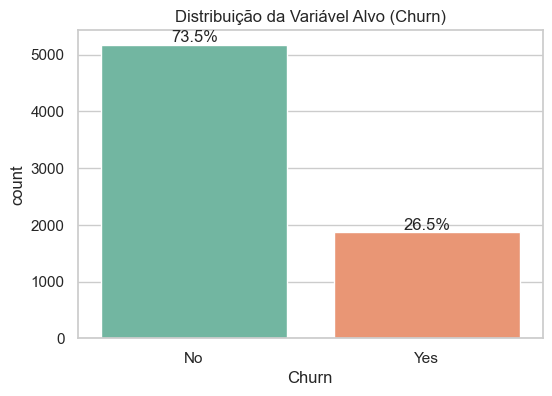

In [29]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='Churn', palette='Set2', hue='Churn', legend=False)
plt.title('Distribuição da Variável Alvo (Churn)')

total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.1
    y = p.get_y() + p.get_height() + 50
    ax.annotate(percentage, (x, y))
plt.show()

### Variáveis Numéricas Contínuas
Avaliando a distribuição do tempo de permanência (`tenure`) e das cobranças (`MonthlyCharges` e `TotalCharges`), podemos extrair a "fotografia comportamental" geral do ecossistema da operadora:

**Conclusões Visuais:**
1. **Distribuição Bimodal do Tenure:** O gráfico do tempo de casa revela dois grandes picos nas extremidades. A operadora tem uma enxurrada de clientes recém-chegados (0-5 meses) e um bloco gigantesco de clientes extremamente fiéis (mais de 60 meses). O "meio do caminho" é muito menos populoso, sugerindo que *se o cliente sobrevive aos primeiros meses de "onboarding", ele tende a ficar por muitos anos*.
2. **Distribuição de Cobrança Mensal:** A maioria esmagadora da base paga um valor baixo (ao redor de $20). Este é possivelmente o plano de entrada / sobrevivência da empresa. Valores premium (acima de $70) são distribuídos de forma mais ampla.
3. **Distribuição de Cobrança Total:** Como esperado da matemática, segue uma curva exponencial decrescente, fortemente atrelada à massa gigantesca de clientes mais novos que ainda acumularam pouca fatura ao longo do tempo.

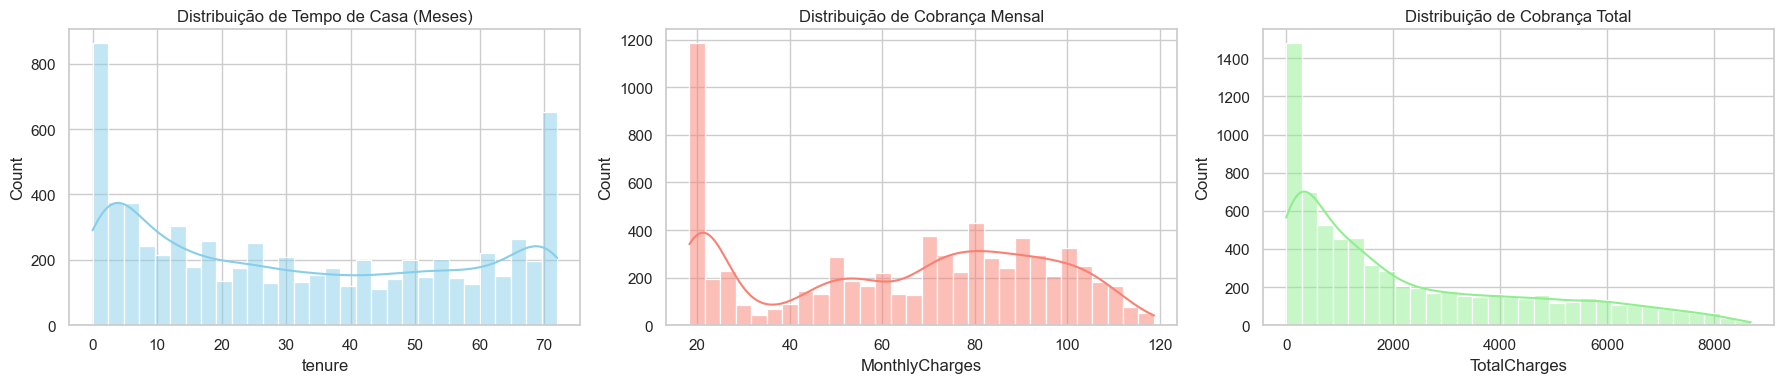

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.histplot(df['tenure'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribuição de Tempo de Casa (Meses)')

sns.histplot(df['MonthlyCharges'], bins=30, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribuição de Cobrança Mensal')

sns.histplot(df['TotalCharges'], bins=30, kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Distribuição de Cobrança Total')

plt.tight_layout()
plt.show()

## 4. Análise Bivariada: Identificando os Gatilhos de Churn
A Análise Bivariada é o coração absoluto da Análise Exploratória (EDA). Aqui, nós cruzamos as *features* individuais contra a nossa variável alvo (`Churn`) para descobrir o que, de fato, motiva um cliente a tomar a decisão de cancelamento. Selecionamos as três correlações mais emblemáticas para embasar as ações da Diretoria Executiva.

**Conclusões Diretas da Plotagem:**
1. **O Perigo do Início (Tenure):** O primeiro boxplot deixa claríssimo que a mediana de tempo de casa de quem cancela é muito menor. Clientes com baixo *tenure* (particularmente no primeiro ano) são altamente voláteis. O modelo fatalmente pesará o baixo tenure como o maior fator de risco.
2. **Sensibilidade a Preço (Monthly Charges):** O segundo boxplot inverte a lógica. A mediana da fatura de quem cancela é sensivelmente maior do que a de quem fica. Clientes pagando valores inflados (plano premium ou sem desconto) abandonam o navio com mais facilidade.
3. **A Prisão do Contrato (Contract):** O *countplot* é a prova de fogo. A esmagadora maioria absoluta dos cancelamentos vem de clientes com contrato *Month-to-month* (Mês a Mês). Contratos de 1 ou 2 anos possuem churn quase nulo. Ofertar o travamento do cliente num contrato anual em troca de desconto parece ser a ação de retenção mais óbvia a ser aplicada na saída do nosso futuro modelo preditivo.

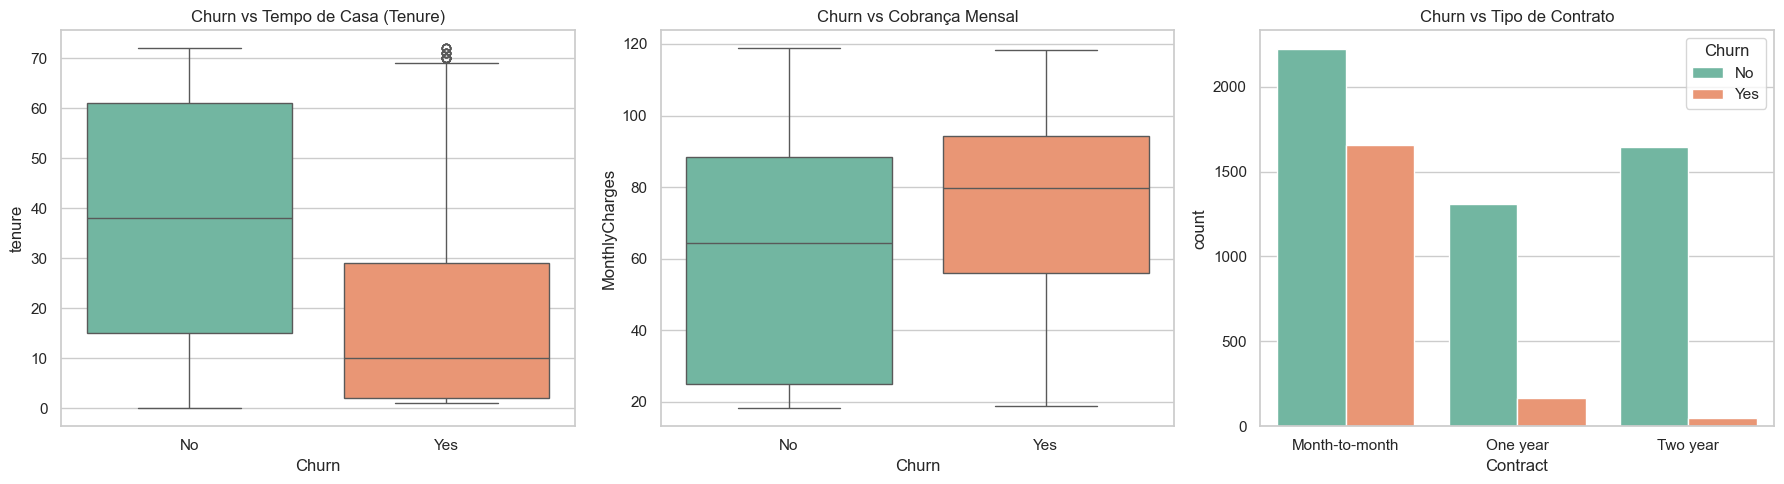

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Quem cancela fica menos tempo na operadora?
sns.boxplot(data=df, x='Churn', y='tenure', ax=axes[0], palette='Set2', hue='Churn', legend=False)
axes[0].set_title('Churn vs Tempo de Casa (Tenure)')

# 2. Quem cancela gasta mais por mês?
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[1], palette='Set2', hue='Churn', legend=False)
axes[1].set_title('Churn vs Cobrança Mensal')

# 3. O contrato mensal afeta severamente o churn?
sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[2], palette='Set2')
axes[2].set_title('Churn vs Tipo de Contrato')

plt.tight_layout()
plt.show()

## 4. Modelagem: Baselines
Utilizaremos um `DummyClassifier` (chute mais provável) e uma `LogisticRegression` simples para determinarmos a régua de corte. Tudo será trackeado com MLflow.

In [32]:
import os

# Configura o tracking URI na raiz do projeto
mlflow.set_tracking_uri("sqlite:///../mlflow.db")

experiment_name = 'churn_baselines'
# Força o artifact_location a ser um caminho relativo, não expondo diretórios locais
relative_artifact_path = "file:../mlruns"

if not mlflow.get_experiment_by_name(experiment_name):
    mlflow.create_experiment(name=experiment_name, artifact_location=relative_artifact_path)

exp = mlflow.set_experiment(experiment_name) # Suprime o output

## 5. Preparação de Dados (Pipelines de Scikit-Learn)

Com o profundo entendimento do comportamento do cliente extraído na etapa de EDA, chegou a hora de transmutar esses dados brutos para o formato exigido pelos motores matemáticos de Machine Learning.

**1. Separação Estratificada (Train-Test Split):**
Dividimos os dados aleatoriamente em 80% para Treinamento e 20% para Teste (Holdout). Utilizamos o argumento `stratify=y` de forma compulsória para garantir que a distribuição de cancelamentos (os ~26% de Churn vistos no gráfico univariado) seja exatamente a mesma em ambos os conjuntos, evitando um viés de amostragem desastroso (onde o teste poderia vir sem nenhum churn por puro azar estatístico).

**2. Transformação Segura de Colunas (ColumnTransformer):**
Modelos lineares e Redes Neurais não entendem palavras ("Yes"/"No"), nem conseguem convergir os pesos da rede rapidamente se uma coluna possui valores na casa das dezenas (`tenure`) e outra na casa dos milhares (`TotalCharges`). O Pipeline garante que essa conversão aconteça sem *Data Leakage* (Vazamento de Dados da base de teste para a de treino).
* **Para as Numéricas:** Utilizamos o `StandardScaler`, que centraliza a distribuição de cada coluna em zero e forca um desvio padrão de 1. Isso será um pilar fundamental para os gradientes da nossa futura MLP em PyTorch na Etapa 2.
* **Para as Categóricas:** Utilizamos o `OneHotEncoder(drop='first')`, que cria sub-colunas binárias absolutas (1 ou 0) para cada categoria textual. O uso agressivo de `drop='first'` evita a armadilha da multicolinearidade perfeita (ex: se o cliente não é 'Female', a matemática já deduz que ele é 'Male', então não precisamos inchar a matriz com duas colunas redundantes).

In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Separando variáveis (ignorando ID que não carrega padrão comportamental)
X = df.drop(columns=['Churn', 'customerID'])
y = df['Churn'].map({'Yes': 1, 'No': 0})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = [col for col in X.columns if col not in numeric_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
    ])

print("Shape Treino:", X_train.shape)
print("Shape Teste:", X_test.shape)

Shape Treino: (5634, 19)
Shape Teste: (1409, 19)


## 6. Função de Avaliação e Rastreio Contínuo (MLflow Tracking)

Para garantir a **reprodutibilidade técnica e a rastreabilidade dos ativos**, uma prática inegociável na Engenharia de MLOps moderna, o projeto utiliza a ferramenta `MLflow`. 

Abaixo, construímos uma função centralizadora robusta (`evaluate_and_log`) que isola toda a complexidade de avaliação. O pipeline dela consiste em:
1. **Validação Cruzada Estratificada:** Recebe o modelo e aplica 5 folds no conjunto de Treino, extraindo a média de performance para provar que o modelo generaliza e não está com overfitting.
2. **Inferência Final (Holdout):** Gera predições no conjunto isolado de Teste e gera tanto predições absolutas (classes) quanto as probabilidades contínuas (valores entre 0.00 e 1.00, que são vitais para as curvas matemáticas como o AUC-ROC).
2. **Métricas de Negócio:** Computa as 3 métricas estipuladas rigorosamente no nosso ML Canvas (`AUC-ROC`, `PR-AUC` e `F1-Score`).
3. **Persistência de Estado (Tracking):** Abre uma "run" virtual no MLflow, guardando esses scores no nosso banco de dados relacional (`mlflow.db`), juntamente com uma serialização nativa (artefato) do modelo treinado. 
Dessa forma, a equipe de cientistas e engenheiros nunca perderá o histórico ou os pesos das experimentações passadas.

In [34]:
import logging
# Oculta os warnings internos de depreciação e serialização do MLflow
logging.getLogger('mlflow').setLevel(logging.ERROR)

from sklearn.metrics import recall_score, roc_auc_score, f1_score, average_precision_score, classification_report
from sklearn.model_selection import StratifiedKFold, cross_validate
import numpy as np

def evaluate_and_log(model, X_train, y_train, X_test, y_test, model_name):
    # 1. Validação Cruzada Estratificada no conjunto de treino (Boas Práticas FIAP)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scoring = {'auc': 'roc_auc', 'f1': 'f1', 'pr_auc': 'average_precision'}
    
    # Roda o cross_validate e pega a média das métricas (isento de overfitting)
    cv_results = cross_validate(model, X_train, y_train, cv=skf, scoring=scoring)
    cv_auc = np.mean(cv_results['test_auc'])
    cv_f1 = np.mean(cv_results['test_f1'])
    cv_pr_auc = np.mean(cv_results['test_pr_auc'])
    
    print(f"--- Validação Cruzada Estratificada (5 Folds): {model_name} ---")
    print(f"CV AUC-ROC: {cv_auc:.4f} | CV PR-AUC: {cv_pr_auc:.4f} | CV F1-Score: {cv_f1:.4f}\n")
    
    # 2. Avaliação final no conjunto de Holdout (Teste)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    test_auc = roc_auc_score(y_test, y_proba)
    test_pr_auc = average_precision_score(y_test, y_proba)
    test_f1 = f1_score(y_test, y_pred)
    test_recall = recall_score(y_test, y_pred, zero_division=0)
    
    print(f"--- Teste Final (Holdout): {model_name} ---")
    print(classification_report(y_test, y_pred, zero_division=0))
    print(f"Holdout AUC-ROC: {test_auc:.4f} | Holdout PR-AUC: {test_pr_auc:.4f} | Holdout F1-Score: {test_f1:.4f} | Holdout Recall: {test_recall:.4f}\n")
    
    # 3. MLflow Tracking
    with mlflow.start_run(run_name=model_name):
        mlflow.log_param("model_type", model_name)
        mlflow.log_param("dataset_version", "v1.0") # Obrigatório pela Rubrica FIAP
        
        # Logando as métricas da validação cruzada
        mlflow.log_metric("cv_auc_roc", cv_auc)
        mlflow.log_metric("cv_pr_auc", cv_pr_auc)
        mlflow.log_metric("cv_f1_score", cv_f1)
        
        # Logando as métricas do holdout de teste
        mlflow.log_metric("test_auc_roc", test_auc)
        mlflow.log_metric("test_pr_auc", test_pr_auc)
        mlflow.log_metric("test_f1_score", test_f1)
        mlflow.log_metric("test_recall", test_recall)
        
        mlflow.sklearn.log_model(model, "model_baseline")

## 7. Construção dos Modelos Baselines e Rastreamento (MLflow)

Para não poluirmos o notebook com dezenas de células repetitivas, consolidamos nossos 3 modelos de baseline (`DummyClassifier`, `LogisticRegression` e `RandomForestClassifier`) em um dicionário. 

Um loop iterará sobre eles, conectará o nosso `preprocessor` estrito para evitar *Data Leakage*, executará a Validação Cruzada Estratificada, e registrará todas as 4 métricas exigidas (AUC-ROC, PR-AUC, F1-Score e Recall) diretamente no MLflow.

In [35]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, recall_score, classification_report

def evaluate_baseline(model, X_train, y_train, X_test, y_test, model_name):
    print(f"\n{'='*50}")
    print(f"Treinando: {model_name}")
    print(f"{'='*50}")
    
    # 1. Validação Cruzada (Cross-Validation)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scoring = {'auc': 'roc_auc', 'pr_auc': 'average_precision', 'f1': 'f1', 'recall': 'recall'}
    
    cv_results = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    
    cv_auc = cv_results['test_auc'].mean()
    cv_pr_auc = cv_results['test_pr_auc'].mean()
    cv_f1 = cv_results['test_f1'].mean()
    cv_recall = cv_results['test_recall'].mean()
    
    print(f"--- Cross-Validation (5 Folds) ---")
    print(f"CV AUC-ROC: {cv_auc:.4f} | CV PR-AUC: {cv_pr_auc:.4f} | CV F1: {cv_f1:.4f} | CV Recall: {cv_recall:.4f}")
    
    # 2. Treinamento Final no Holdout
    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
    
    test_auc = roc_auc_score(y_test, y_proba)
    test_pr_auc = average_precision_score(y_test, y_proba)
    test_f1 = f1_score(y_test, y_pred)
    test_recall = recall_score(y_test, y_pred, zero_division=0)
    
    print(f"\n--- Teste Final (Holdout) ---")
    print(classification_report(y_test, y_pred, zero_division=0))
    print(f"Holdout AUC-ROC: {test_auc:.4f} | PR-AUC: {test_pr_auc:.4f} | F1: {test_f1:.4f} | Recall: {test_recall:.4f}\n")
    
    # 3. MLflow Tracking
    with mlflow.start_run(run_name=model_name):
        mlflow.log_param("model_type", model_name)
        mlflow.log_param("dataset_version", "v1.0")
        
        mlflow.log_metric("cv_auc_roc", cv_auc)
        mlflow.log_metric("cv_pr_auc", cv_pr_auc)
        mlflow.log_metric("cv_f1_score", cv_f1)
        mlflow.log_metric("cv_recall", cv_recall)
        
        mlflow.log_metric("test_auc_roc", test_auc)
        mlflow.log_metric("test_pr_auc", test_pr_auc)
        mlflow.log_metric("test_f1_score", test_f1)
        mlflow.log_metric("test_recall", test_recall)
        
        mlflow.sklearn.log_model(model, "model_baseline")

# Dicionário de Modelos Base
models = {
    "DummyClassifier": DummyClassifier(strategy='stratified', random_state=42),
    "LogisticRegression": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    "RandomForestClassifier": RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced')
}

# Loop de Treinamento Unificado
for name, clf in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', clf)
    ])
    evaluate_baseline(pipeline, X_train, y_train, X_test, y_test, name)


Treinando: DummyClassifier
--- Cross-Validation (5 Folds) ---
CV AUC-ROC: 0.5065 | CV PR-AUC: 0.2686 | CV F1: 0.2762 | CV Recall: 0.2776

--- Teste Final (Holdout) ---
              precision    recall  f1-score   support

           0       0.74      0.74      0.74      1035
           1       0.29      0.29      0.29       374

    accuracy                           0.62      1409
   macro avg       0.52      0.52      0.52      1409
weighted avg       0.62      0.62      0.62      1409

Holdout AUC-ROC: 0.5163 | PR-AUC: 0.2723 | F1: 0.2903 | Recall: 0.2914


Treinando: LogisticRegression
--- Cross-Validation (5 Folds) ---
CV AUC-ROC: 0.8459 | CV PR-AUC: 0.6599 | CV F1: 0.6296 | CV Recall: 0.8020

--- Teste Final (Holdout) ---
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.7